In [14]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
import numpy as np
import tensorflow_datasets as tfds

In [15]:
ds_train = tfds.load("emnist/balanced", split="train", as_supervised=True)
ds_test = tfds.load("emnist/balanced", split="test", as_supervised=True)

In [16]:
x_train = np.array([x for x, y in tfds.as_numpy(ds_train)])
y_train = np.array([y for x, y in tfds.as_numpy(ds_train)])

x_test = np.array([x for x, y in tfds.as_numpy(ds_test)])
y_test = np.array([y for x, y in tfds.as_numpy(ds_test)])

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

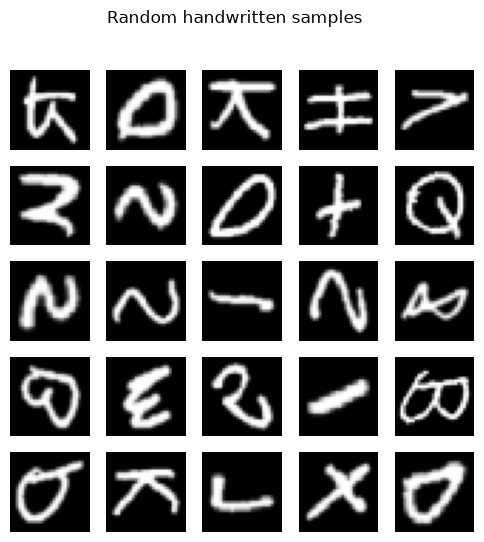

In [17]:
idx = np.random.choice(len(x_train), 25, replace=False)
plt.figure(figsize=(6, 6))
for i, j in enumerate(idx):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[j].squeeze(), cmap="gray")
    plt.axis("off")
plt.suptitle("Random handwritten samples")
plt.show()

In [18]:
class Encoder(Model):
    def __init__(self):
        super().__init__()
        self.net = tf.keras.Sequential([
            layers.Input((28, 28, 1)),
            layers.Flatten(),
            layers.Dense(512, activation='relu'),
            layers.Dense(256, activation='relu'),
            layers.Dense(128, activation='relu'),
            layers.Dense(2)
        ])
    def call(self, x): return self.net(x)

In [19]:
class Decoder(Model):
    def __init__(self):
        super().__init__()
        self.net = tf.keras.Sequential([
            layers.Input((2,)),
            layers.Dense(128, activation='relu'),
            layers.Dense(256, activation='relu'),
            layers.Dense(512, activation='relu'),
            layers.Dense(784, activation='sigmoid'),
            layers.Reshape((28, 28, 1))
        ])
    def call(self, z): return self.net(z)

In [20]:
class AutoEncoder(Model):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()
    def call(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [21]:
def train(loss_fn, name):
    ae = AutoEncoder()
    ae.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=loss_fn)
    h = ae.fit(x_train, x_train,
               validation_data=(x_test, x_test),
               epochs=20, batch_size=128)
    return ae, h

In [22]:
mse_model, mse_hist = train("mse", "MSE")
bce_model, bce_hist = train(tf.keras.losses.BinaryCrossentropy(), "BCE")

Epoch 1/20
882/882 ━━━━━━━━━━━━━━━━━━━━ 36s 34ms/step - loss: 0.0700 - val_loss: 0.0629
Epoch 2/20
882/882 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0609 - val_loss: 0.0595
Epoch 3/20
882/882 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0585 - val_loss: 0.0574
Epoch 4/20
882/882 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0569 - val_loss: 0.0563
Epoch 5/20
882/882 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0560 - val_loss: 0.0566
Epoch 6/20
882/882 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0553 - val_loss: 0.0552
Epoch 7/20
882/882 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0547 - val_loss: 0.0543
Epoch 8/20
882/882 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0542 - val_loss: 0.0542
Epoch 9/20
882/882 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0536 - val_loss: 0.0537
Epoch 10/20
882/882 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0532 - val_loss: 0.0532
Epoch 11/20
882/882 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0529 - val_loss: 0.0529
Epoch 12/20
882/882 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/st

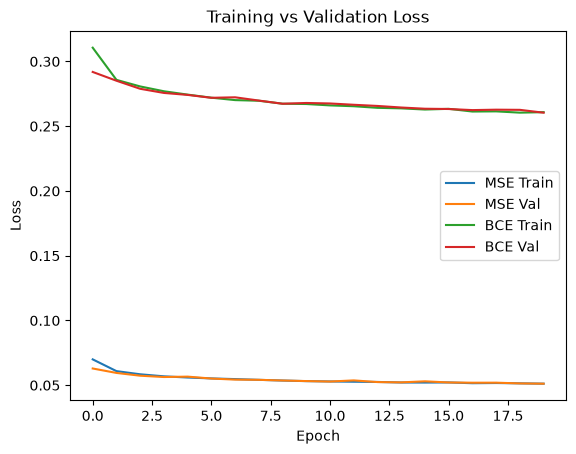

In [23]:
plt.figure()
plt.plot(mse_hist.history["loss"], label="MSE Train")
plt.plot(mse_hist.history["val_loss"], label="MSE Val")
plt.plot(bce_hist.history["loss"], label="BCE Train")
plt.plot(bce_hist.history["val_loss"], label="BCE Val")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.title("Training vs Validation Loss")
plt.show()

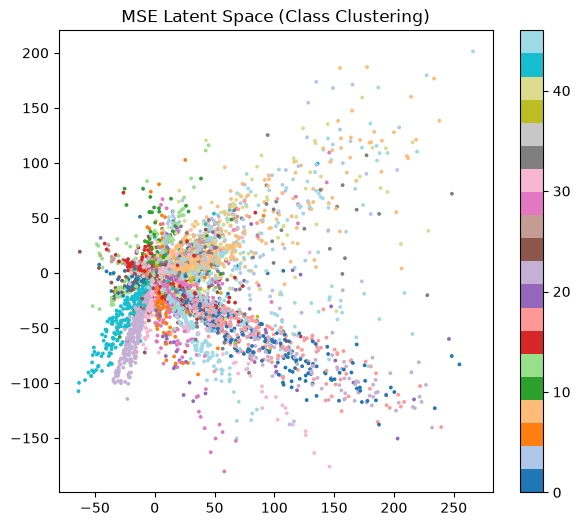

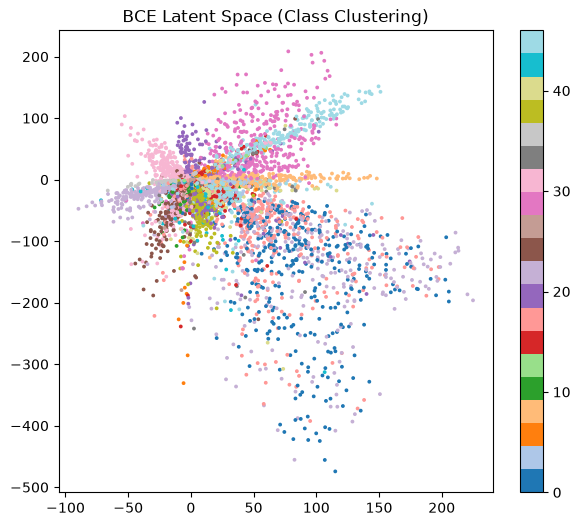

In [24]:
def latent_plot(model, title):
    z = model.encoder.predict(x_test, verbose=0)
    plt.figure(figsize=(7, 6))
    plt.scatter(z[:, 0], z[:, 1], c=y_test, s=3, cmap='tab20')
    plt.colorbar()
    plt.title(title)
    plt.show()

latent_plot(mse_model, "MSE Latent Space (Class Clustering)")
latent_plot(bce_model, "BCE Latent Space (Class Clustering)")

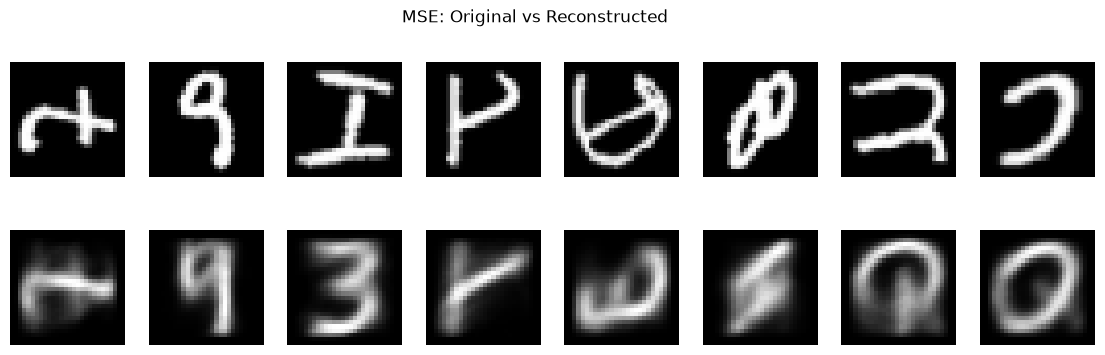

MSE Mean Reconstruction Error: 0.14868382


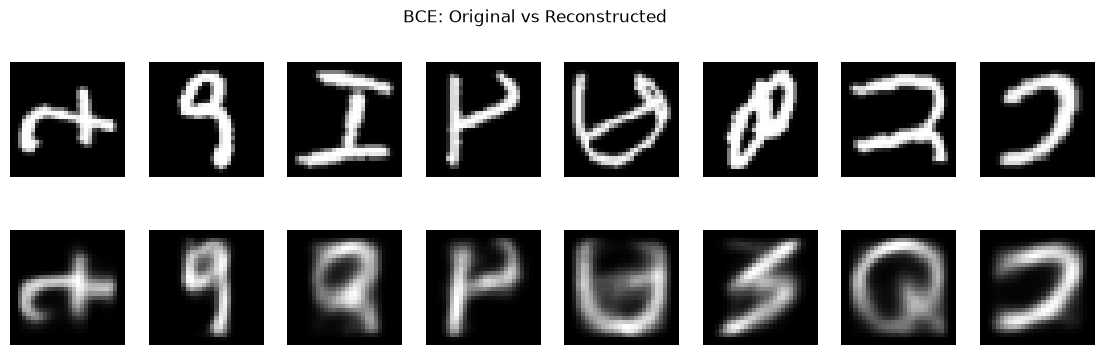

BCE Mean Reconstruction Error: 0.15139514


In [25]:
sel = np.random.choice(len(x_test), 8)
recon_errors = {}
for model, title in [(mse_model, "MSE"), (bce_model, "BCE")]:
    recon = model.predict(x_test[sel], verbose=0)
    fig, ax = plt.subplots(2, 8, figsize=(14, 4))
    fig.suptitle(f"{title}: Original vs Reconstructed")
    errs = []
    for i in range(8):
        ax[0, i].imshow(x_test[sel[i]].squeeze(), cmap="gray")
        ax[1, i].imshow(recon[i].squeeze(), cmap="gray")
        ax[0, i].axis("off"); ax[1, i].axis("off")
        errs.append(np.mean((x_test[sel[i]] - recon[i]) ** 2))
    plt.show()
    recon_errors[title] = np.mean(errs)
    print(title, "Mean Reconstruction Error:", recon_errors[title])

Final MSE val loss: 0.0511903315782547
Final BCE val loss: 0.2604169547557831
Mean reconstruction error (MSE model): 0.14868382
Mean reconstruction error (BCE model): 0.15139514


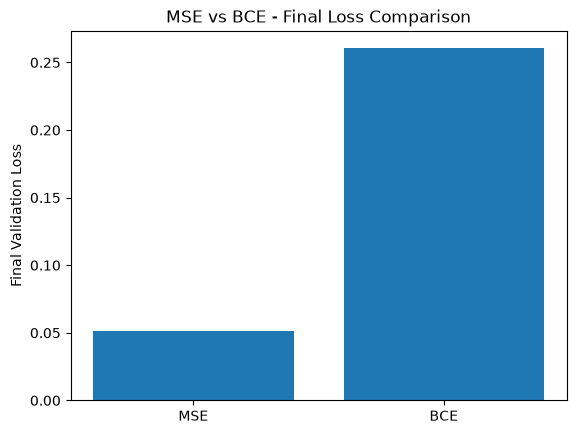

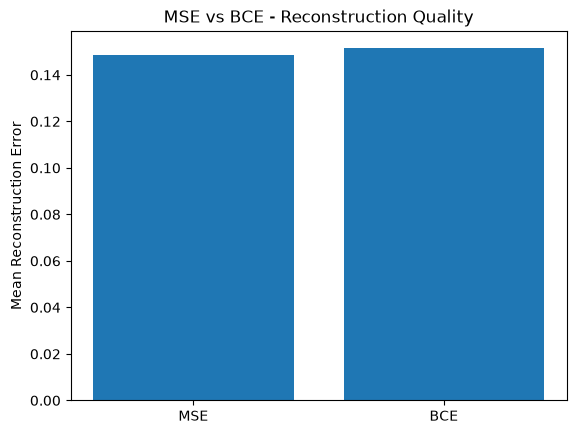

In [26]:
print("Final MSE val loss:", mse_hist.history["val_loss"][-1])
print("Final BCE val loss:", bce_hist.history["val_loss"][-1])
print("Mean reconstruction error (MSE model):", recon_errors["MSE"])
print("Mean reconstruction error (BCE model):", recon_errors["BCE"])

plt.figure()
plt.bar(["MSE", "BCE"], [mse_hist.history["val_loss"][-1], bce_hist.history["val_loss"][-1]])
plt.ylabel("Final Validation Loss")
plt.title("MSE vs BCE - Final Loss Comparison")
plt.show()

plt.figure()
plt.bar(["MSE", "BCE"], [recon_errors["MSE"], recon_errors["BCE"]])
plt.ylabel("Mean Reconstruction Error")
plt.title("MSE vs BCE - Reconstruction Quality")
plt.show()